# SALT3 Single Spectrum Fitting
This notebook allows you to load a single supernova spectrum, fit it using the SALT3 model with `dynesty`, and visualize the results including convergence plots, corner plots, and the best-fit model compared to the data.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sncosmo
import dynesty
import corner
from dynesty import plotting as dyplot
from astropy.time import Time
from datetime import datetime

# Settings
SPECTRA_DIR = "../data/all_spectra"
PARAM_FILE = "../data/cfasnIa_param.dat"
SNID_RESULTS = "../outputs/method_comparison/cfa_SNID_results.csv"
MODEL_NAME = 'salt3'
NLIVE = 200

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('default')

## 1. Helper Functions

In [3]:
def parse_param_file(file_path):
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.split()
            sn_name = parts[0].lower()
            params[sn_name] = {'z': float(parts[1]), 'mjd_max': float(parts[2])}
    return params

def load_flm_spectrum(file_path):
    data = np.genfromtxt(file_path, invalid_raise=False)
    wave, flux = data[:, 0], data[:, 1]
    err = data[:, 2] if data.shape[1] >= 3 else 0.1 * np.abs(flux)
    mask = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    return wave[mask], flux[mask], err[mask]

def run_fit(wavelength, flux, flux_err, nlive, method='nuis', redshift=None):
    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)
    
    if method == 'full':
        params = ['t0', 'x1', 'c', 'log10_x0']
        priors = {'t0': (-100, 100), 'x1': (-4, 18), 'c': (-0.8, 0.8), 'log10_x0': (-20, -2)}
    else:
        params = ['t0', 'x1', 'c']
        priors = {'t0': (-100, 100), 'x1': (-4, 18), 'c': (-0.8, 0.8)}

    def pt(u):
        t = np.zeros_like(u)
        for i, p in enumerate(params):
            low, high = priors[p]
            t[i] = u[i] * (high - low) + low
        return t

    def ll(t):
        p_dict = dict(zip(params, t))
        if 'log10_x0' in p_dict: p_dict['x0'] = 10**p_dict.pop('log10_x0')
        model.set(**p_dict)
        try:
            if method == 'nuis':
                model.set(x0=1.0)
                m_flux_unit = model.flux(0.0, wavelength)
                w = 1.0 / flux_err**2
                num, den = np.sum(flux * m_flux_unit * w), np.sum(m_flux_unit**2 * w)
                if den <= 0: return -1e10
                x0_best = num / den
                if x0_best <= 0: return -1e10
                chisq = np.sum(((flux - x0_best * m_flux_unit) / flux_err)**2)
            else:
                m_flux = model.flux(0.0, wavelength)
                chisq = np.sum(((flux - m_flux) / flux_err)**2)
            return -0.5 * chisq if not np.isnan(chisq) else -1e10
        except: return -1e10

    sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=nlive, sample='rslice')
    sampler.run_nested()
    return sampler.results, params

## 2. Load Data
Select a spectrum from the `data/all_spectra` directory.

Found metadata for sn2003hu-20030930.16-fast.flm: z=0.075, mjd_max=52901.1
True Phase: 10.29 d
SNID Phase: 8.71 d


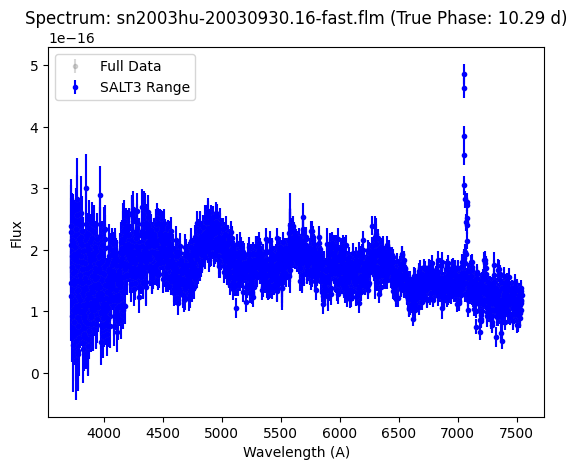

In [23]:
# Example file
FILENAME = 'sn2003hu-20030930.16-fast.flm'
METHOD = 'nuis'  # 'nuis' (marginalized x0) or 'full' (sampled log10_x0)

sn_params = parse_param_file(PARAM_FILE)
sn_id = FILENAME.split('-')[0]
param_lookup = sn_id[2:] if sn_id.startswith('sn') else sn_id
p = sn_params.get(param_lookup.lower())

# Get True Phase from SNID results if available
true_phase = None
snid_phase = None
if os.path.exists(SNID_RESULTS):
    df_snid = pd.read_csv(SNID_RESULTS)
    row = df_snid[df_snid['Filename'] == FILENAME]
    if not row.empty:
        true_phase = row['Age_(days)'].values[0]
        snid_phase = row['bootstrap_age'].values[0]

if p:
    print(f"Found metadata for {FILENAME}: z={p['z']}, mjd_max={p['mjd_max']}")
    if true_phase is not None:
        print(f"True Phase: {true_phase:.2f} d")
        print(f"SNID Phase: {snid_phase:.2f} d")
    wave, flux, err = load_flm_spectrum(os.path.join(SPECTRA_DIR, FILENAME))
    
    # Apply SALT3 wavelength range mask
    mask = (wave > 3500) & (wave < 8000)
    wave_f, flux_f, err_f = wave[mask], flux[mask], err[mask]
    
    plt.errorbar(wave, flux, yerr=err, fmt='.', color='gray', alpha=0.3, label='Full Data')
    plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='blue', label='SALT3 Range')
    title = f"Spectrum: {FILENAME}"
    if true_phase is not None: title += f" (True Phase: {true_phase:.2f} d)"
    plt.title(title)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.legend()
    plt.show()
else:
    print(f"Error: Metadata for {sn_id} not found in {PARAM_FILE}")

## 3. Run Nested Sampling

In [5]:
print(f"Running {METHOD} fit for {FILENAME}...")
results, params_names = run_fit(wave_f, flux_f, err_f, NLIVE, method=METHOD, redshift=p['z'])
print("Fit complete.")

Running nuis fit for sn2003hu-20030930.16-fast.flm...


iter: 3521 | +200 | bound: 76 | nc: 1 | ncall: 98046 | eff(%):  3.803 | loglstar:   -inf < -3568.653 <    inf | logz: -3584.854 +/-    nan | dlogz:  0.001 >  0.209                                   

Fit complete.


## 4. Convergence Plots
Check if the evidence has converged and look at the parameter traces.

/Users/pxm588@student.bham.ac.uk/miniconda3/envs/testsuite/lib/python3.13/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


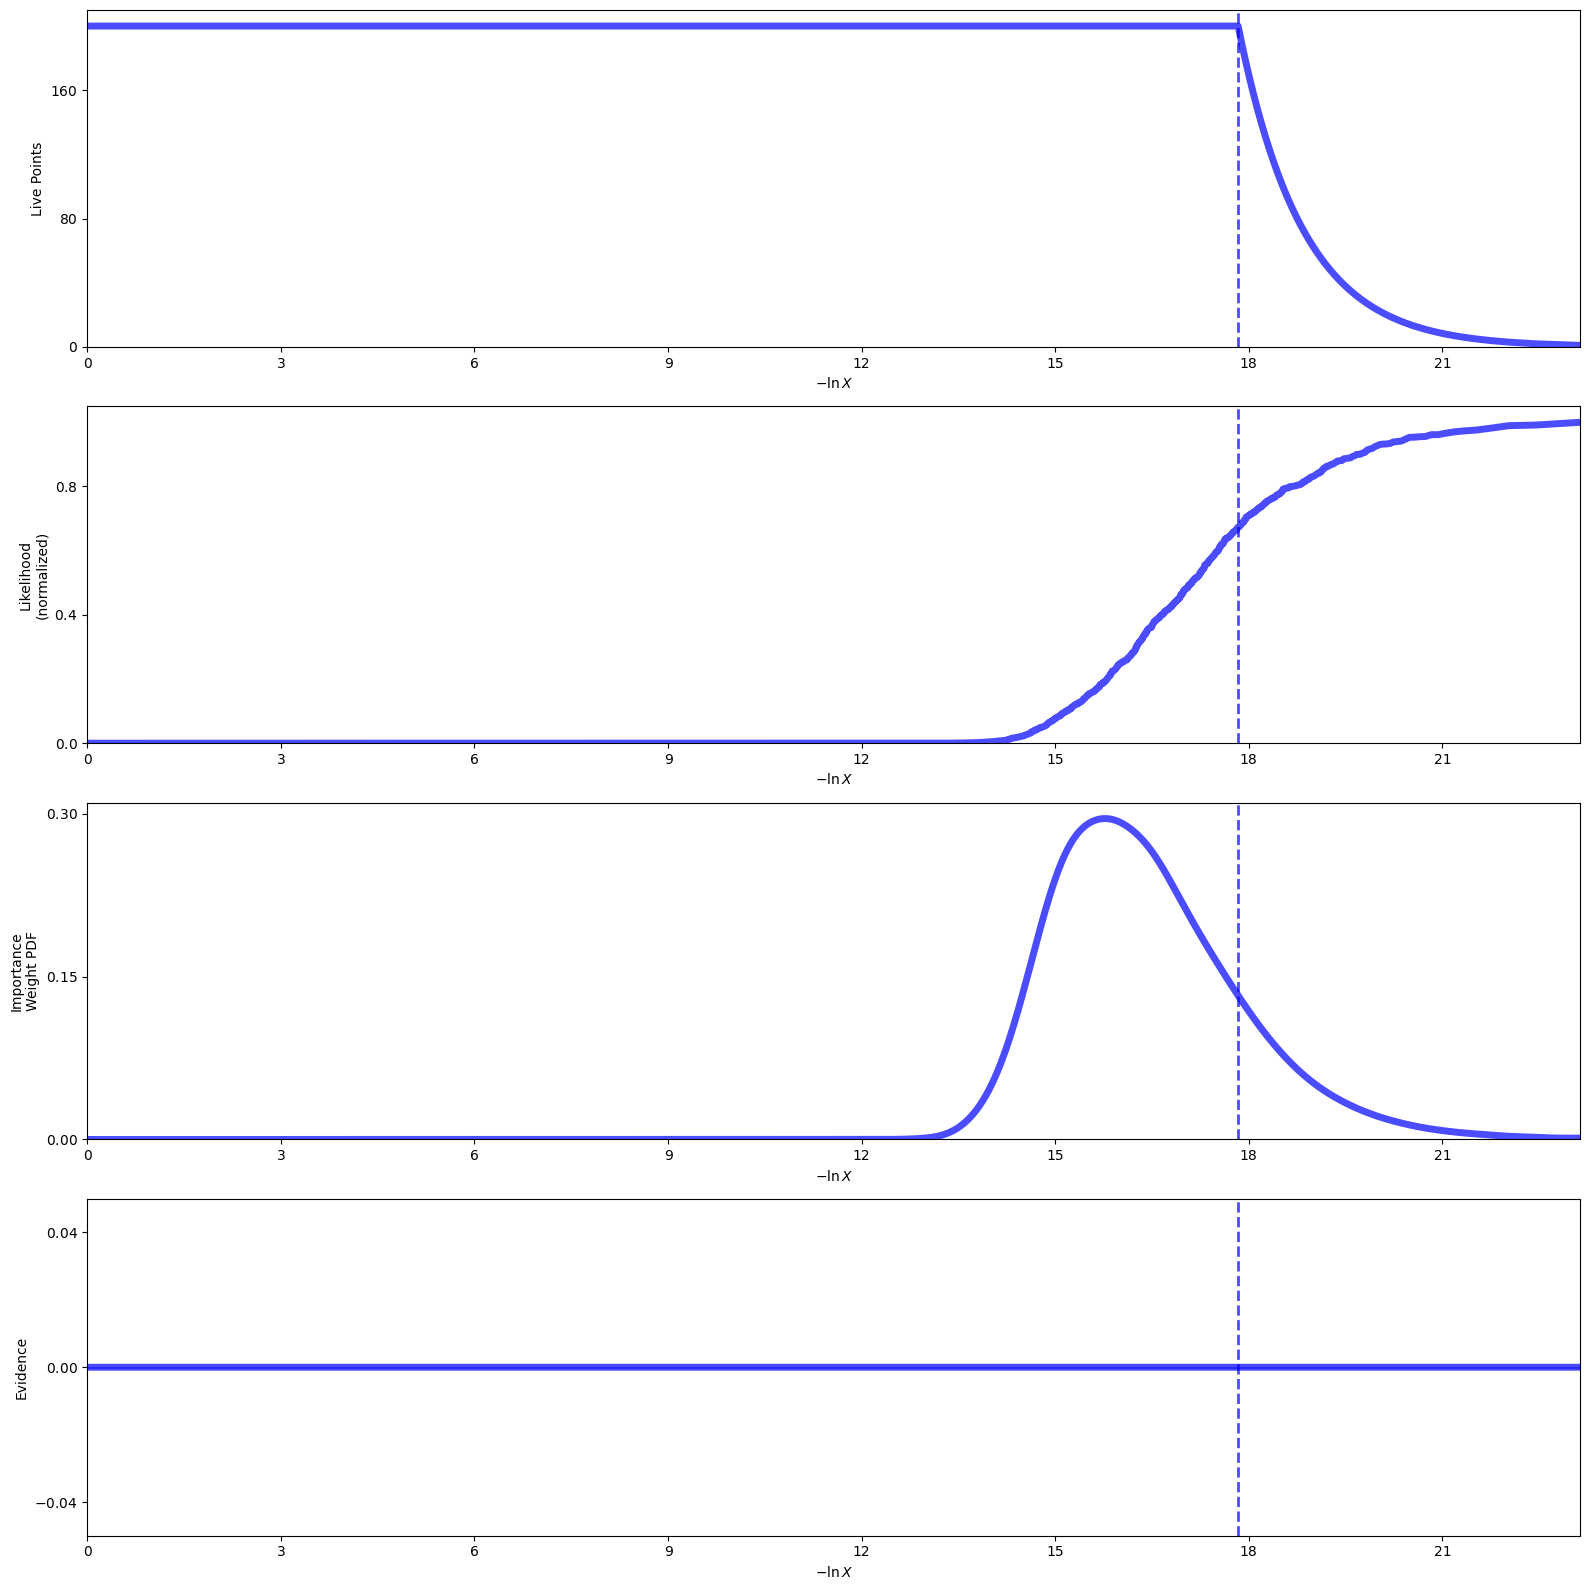

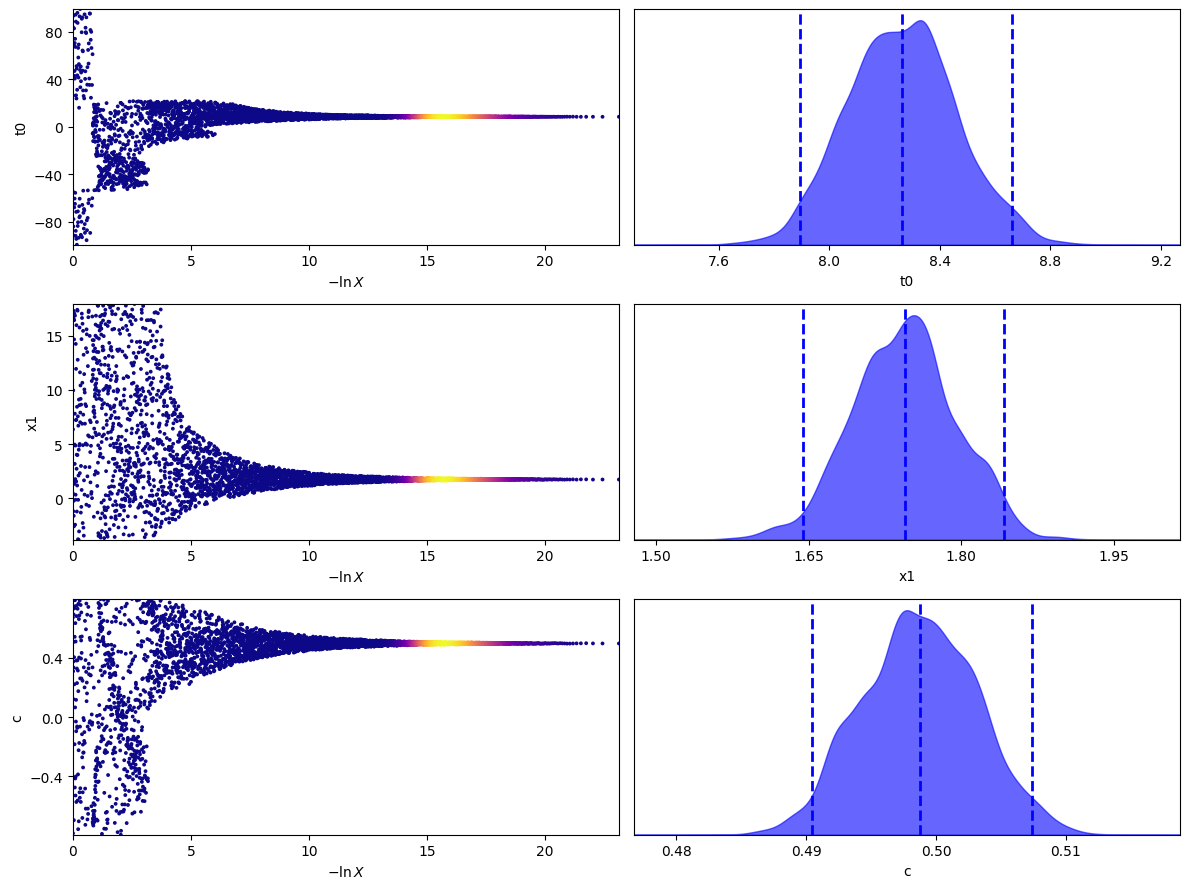

In [6]:
fig, axes = dyplot.runplot(results)
plt.tight_layout()
plt.show()

fig, axes = dyplot.traceplot(results, labels=params_names)
plt.tight_layout()
plt.show()

## 5. Corner Plot
Visualize parameter correlations and marginalized distributions.

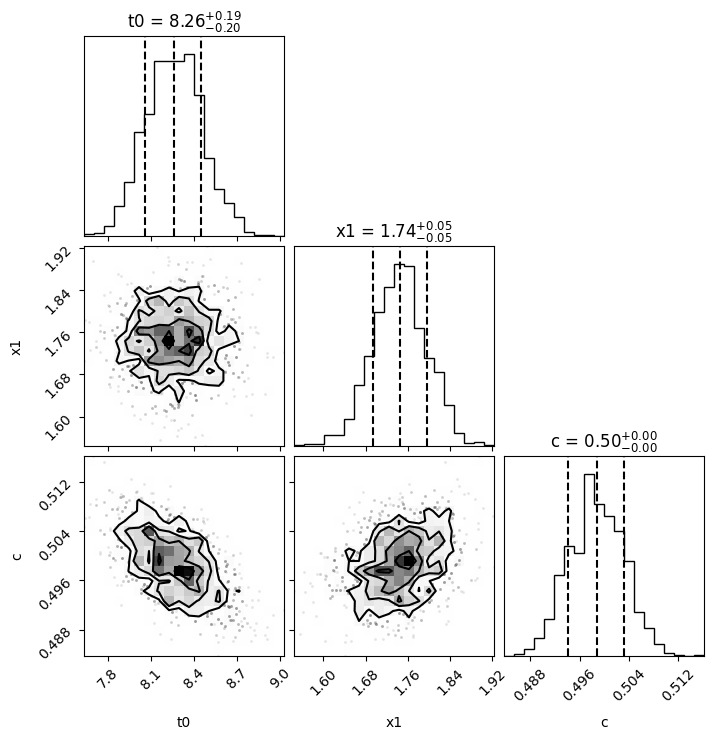

In [7]:
# Resample for equal weights
weights = np.exp(results.logwt - results.logz[-1])
samples = dynesty.utils.resample_equal(results.samples, weights)

fig = corner.corner(samples, labels=params_names, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

## 6. Model vs Data
Overlay the best-fit model on the observed spectrum.

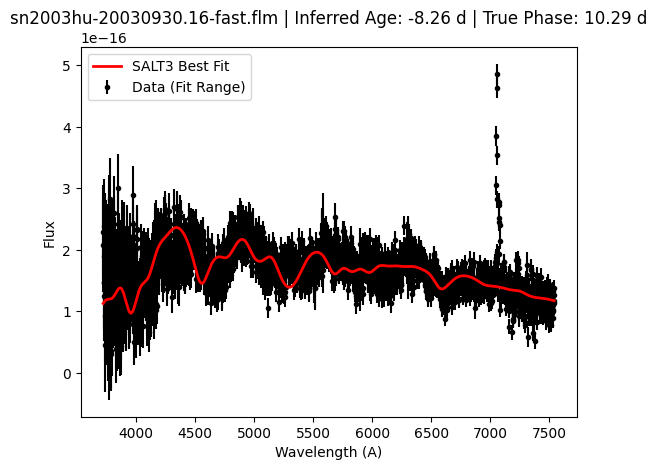

In [8]:
# Get median parameters
med_params = np.median(samples, axis=0)
p_dict = dict(zip(params_names, med_params))

model = sncosmo.Model(source=MODEL_NAME)
model.set(z=p['z'])

if METHOD == 'nuis':
    # Recalculate best x0 for median params
    model.set(**p_dict)
    model.set(x0=1.0)
    m_flux_unit = model.flux(0.0, wave_f)
    w = 1.0 / err_f**2
    x0_best = np.sum(flux_f * m_flux_unit * w) / np.sum(m_flux_unit**2 * w)
    model.set(x0=x0_best)
else:
    p_dict_copy = p_dict.copy()
    if 'log10_x0' in p_dict_copy:
        p_dict_copy['x0'] = 10**p_dict_copy.pop('log10_x0')
    model.set(**p_dict_copy)

model_flux = model.flux(0.0, wave_f)

plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black', label='Data (Fit Range)')
plt.plot(wave_f, model_flux, color='red', lw=2, label='SALT3 Best Fit',zorder=10)

inferred_age = -p_dict['t0']
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [37]:
SNID_DIR = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfa_pipeline/all_spectra_dereddened_snidded_supersnid'

# The number of the comp file we want to pick
no = '01'

base_filename = FILENAME.rsplit('.', 1)[0]

snid_output_name = f"{base_filename}_comp00{no}_snidflux.dat"

compfile = os.path.join(SNID_DIR, snid_output_name)


compwave, compflux, comperr = load_flm_spectrum(compfile)
mask = (compwave > 3500) & (compwave < 8000)
compwave_f, compflux_f, comperr_f = compwave[mask], (compflux[mask]*1e-16)+0.5*1e-16, comperr[mask]*1e-16


In [38]:
print(compwave_f, compflux_f, comperr_f)

[3720.59448 3725.63477 3730.68213 3735.73608 3740.79712 3745.8645
 3750.93945 3756.02075 3761.10913 3766.20435 3771.3064  3776.41553
 3781.53125 3786.6543  3791.78467 3796.92139 3802.0647  3807.21582
 3812.37354 3817.53809 3822.70996 3827.88867 3833.07422 3838.26709
 3843.46655 3848.67358 3853.88745 3859.1084  3864.33618 3869.57153
 3874.81348 3880.06274 3885.31909 3890.58252 3895.85327 3901.1311
 3906.41626 3911.70801 3917.00757 3922.31372 3927.62769 3932.94849
 3938.27637 3943.61206 3948.95435 3954.30396 3959.66113 3965.02539
 3970.39673 3975.77563 3981.16138 3986.55493 3991.95557 3997.36328
 4002.77881 4008.20142 4013.63159 4019.06885 4024.51343 4029.96558
 4035.42529 4040.89185 4046.36646 4051.84814 4057.33691 4062.8335
 4068.3374  4073.84912 4079.36792 4084.89429 4090.42847 4095.96948
 4101.51855 4107.0752  4112.63867 4118.21045 4123.78955 4129.37598
 4134.97021 4140.57178 4146.18115 4151.79785 4157.42285 4163.05469
 4168.69434 4174.3418  4179.99707 4185.66016 4191.33008 4197.0083

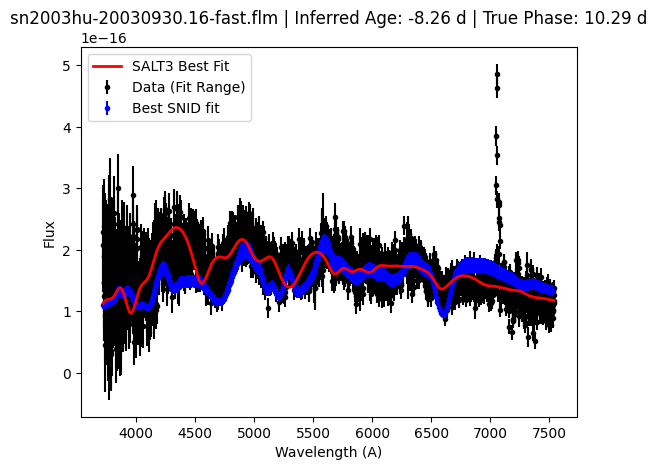

In [39]:
# Get median parameters
med_params = np.median(samples, axis=0)
p_dict = dict(zip(params_names, med_params))

model = sncosmo.Model(source=MODEL_NAME)
model.set(z=p['z'])

if METHOD == 'nuis':
    # Recalculate best x0 for median params
    model.set(**p_dict)
    model.set(x0=1.0)
    m_flux_unit = model.flux(0.0, wave_f)
    w = 1.0 / err_f**2
    x0_best = np.sum(flux_f * m_flux_unit * w) / np.sum(m_flux_unit**2 * w)
    model.set(x0=x0_best)
else:
    p_dict_copy = p_dict.copy()
    if 'log10_x0' in p_dict_copy:
        p_dict_copy['x0'] = 10**p_dict_copy.pop('log10_x0')
    model.set(**p_dict_copy)

model_flux = model.flux(0.0, wave_f)

plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black', label='Data (Fit Range)')
plt.plot(wave_f, model_flux, color='red', lw=2, label='SALT3 Best Fit',zorder=10)
plt.errorbar(compwave_f, compflux_f, yerr=comperr_f, fmt='.', color='blue', label='Best SNID fit', zorder=5)

inferred_age = -p_dict['t0']
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()